## Quantas mulheres foram eleitas para as prefeituras capixabas de 2004 a 2024?

In [150]:
#importando o pandas e o matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Descobrindo a quantidade de mulheres eleitas prefeitas em 2004

In [151]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [152]:
#importando a tabela de votação de 2004
colunas = ['NM_MUNICIPIO', 'DS_CARGO','NM_VOTAVEL','QT_VOTOS','ANO_ELEICAO']
df = pd.read_csv('/content/votacao_secao_2004_ES.csv', delimiter= ';', encoding='latin-1', usecols= colunas)
df.head()

,ANO_ELEICAO,NM_MUNICIPIO,DS_CARGO,NM_VOTAVEL,QT_VOTOS
0,2004,AFONSO CLAUDIO,Prefeito,EDELIO FRANCISCO GUEDES,198
1,2004,AFONSO CLAUDIO,Prefeito,LUIZ TEMOTEO DIAS VIEIRA,93
2,2004,AFONSO CLAUDIO,Prefeito,VICENTE DE PAULO LEITE,14
3,2004,AFONSO CLAUDIO,Prefeito,VOTO BRANCO,8
4,2004,AFONSO CLAUDIO,Prefeito,VOTO NULO,15


In [153]:
mais_votados = df.groupby(['NM_MUNICIPIO','NM_VOTAVEL', 'DS_CARGO', 'ANO_ELEICAO'])['QT_VOTOS'].sum()
mais_votados = mais_votados.reset_index()
mais_votados = mais_votados.loc[mais_votados.groupby(['NM_MUNICIPIO','DS_CARGO'])['QT_VOTOS'].idxmax()]
mais_votados = mais_votados[mais_votados['DS_CARGO'] == 'Prefeito']
mais_votados

,NM_MUNICIPIO,NM_VOTAVEL,DS_CARGO,ANO_ELEICAO,QT_VOTOS
19,AFONSO CLAUDIO,EDELIO FRANCISCO GUEDES,Prefeito,2004,12382
109,AGUA DOCE DO NORTE,ABRAÃO LINCON ELIZEU ...,Prefeito,2004,2892
196,AGUIA BRANCA,JAILSON JOSÉ QUIUQUI,Prefeito,2004,3447
253,ALEGRE,DJALMA DA SILVA SANTOS,Prefeito,2004,15928
344,ALFREDO CHAVES,FERNANDO VIDEIRA LAFAYETTE,Prefeito,2004,5330
391,ALTO RIO NOVO,ALDO SOARES DE OLIVEIRA,Prefeito,2004,1957
474,ANCHIETA,EDIVAL JOSÉ PETRI,Prefeito,2004,6541
612,APIACA,JOSÉ CHIERICI FILHO,Prefeito,2004,2567
660,ARACRUZ,ADEMAR COUTINHO DEVENS,Prefeito,2004,23806
857,ATILIO VIVACQUA,HELIO HUMBERTO LIMA,Prefeito,2004,3924


In [154]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [155]:
#importando a tabela de candidaturas para utilizar a coluna de gênero
colunas = ['NM_UE', 'DS_CARGO', 'NM_CANDIDATO', 'DS_GENERO']
candidatos = pd.read_csv('/content/consulta_cand_2004_ES.csv', delimiter= ';', encoding= 'latin-1', usecols= colunas)
candidatos.head()

,NM_UE,DS_CARGO,NM_CANDIDATO,DS_GENERO
0,ECOPORANGA,VEREADOR,ANA CRISTINA SERPA PORTUGAL,FEMININO
1,ALEGRE,VEREADOR,ALCEBIADES BAPTISTA SOBREIRA,MASCULINO
2,SERRA,PREFEITO,JOÃO GILBERTI SARTÓRIO,MASCULINO
3,MUQUI,VEREADOR,ADDA MARIA MONTEIRO LOBATO MACHADO,FEMININO
4,ANCHIETA,VEREADOR,LUIZ CELSO DE AZEVEDO,MASCULINO


In [156]:
#juntando as tabelas de eleitos e candidatos
nova_tabela = pd.merge(mais_votados, candidatos, left_on= 'NM_VOTAVEL', right_on= 'NM_CANDIDATO', how= 'inner')
nova_tabela

,NM_MUNICIPIO,NM_VOTAVEL,DS_CARGO_x,ANO_ELEICAO,QT_VOTOS,NM_UE,DS_CARGO_y,NM_CANDIDATO,DS_GENERO
0,AFONSO CLAUDIO,EDELIO FRANCISCO GUEDES,Prefeito,2004,12382,AFONSO CLAUDIO,PREFEITO,EDELIO FRANCISCO GUEDES,MASCULINO
1,AGUIA BRANCA,JAILSON JOSÉ QUIUQUI,Prefeito,2004,3447,AGUIA BRANCA,PREFEITO,JAILSON JOSÉ QUIUQUI,MASCULINO
2,ALEGRE,DJALMA DA SILVA SANTOS,Prefeito,2004,15928,ALEGRE,PREFEITO,DJALMA DA SILVA SANTOS,MASCULINO
3,ALFREDO CHAVES,FERNANDO VIDEIRA LAFAYETTE,Prefeito,2004,5330,ALFREDO CHAVES,PREFEITO,FERNANDO VIDEIRA LAFAYETTE,MASCULINO
4,ALTO RIO NOVO,ALDO SOARES DE OLIVEIRA,Prefeito,2004,1957,ALTO RIO NOVO,PREFEITO,ALDO SOARES DE OLIVEIRA,MASCULINO
5,ANCHIETA,EDIVAL JOSÉ PETRI,Prefeito,2004,6541,ANCHIETA,PREFEITO,EDIVAL JOSÉ PETRI,MASCULINO
6,APIACA,JOSÉ CHIERICI FILHO,Prefeito,2004,2567,APIACA,PREFEITO,JOSÉ CHIERICI FILHO,MASCULINO
7,ARACRUZ,ADEMAR COUTINHO DEVENS,Prefeito,2004,23806,ARACRUZ,PREFEITO,ADEMAR COUTINHO DEVENS,MASCULINO
8,ATILIO VIVACQUA,HELIO HUMBERTO LIMA,Prefeito,2004,3924,ATILIO VIVACQUA,PREFEITO,HELIO HUMBERTO LIMA,MASCULINO
9,BAIXO GUANDU,LASTÊNIO LUIZ CARDOSO,Prefeito,2004,8764,BAIXO GUANDU,PREFEITO,LASTÊNIO LUIZ CARDOSO,MASCULINO


In [157]:
#filtrando apenas as mulheres eleitas
mulheres_2004 = nova_tabela[nova_tabela['DS_GENERO'] == 'FEMININO']
mulheres_2004

,NM_MUNICIPIO,NM_VOTAVEL,DS_CARGO_x,ANO_ELEICAO,QT_VOTOS,NM_UE,DS_CARGO_y,NM_CANDIDATO,DS_GENERO
25,FUNDAO,MARIA DULCE RUDIO SOARES,Prefeito,2004,5150,FUNDAO,PREFEITO,MARIA DULCE RUDIO SOARES,FEMININO
35,ITAPEMIRIM,NORMA AYUB ALVES,Prefeito,2004,11127,ITAPEMIRIM,PREFEITO,NORMA AYUB ALVES,FEMININO
47,MIMOSO DO SUL,FLAVIA ROBERTA CYSNE NOVAES RANGEL,Prefeito,2004,6834,MIMOSO DO SUL,PREFEITO,FLAVIA ROBERTA CYSNE NOVAES RANGEL,FEMININO
64,SAO DOMINGOS,ANA IZABEL MALACARNE DE OLIVEIRA,Prefeito,2004,1669,SAO DOMINGOS,PREFEITO,ANA IZABEL MALACARNE DE OLIVEIRA,FEMININO
65,SAO GABRIEL DA PALHA,RAQUEL FERREIRA MAGESTE LESSA,Prefeito,2004,7608,SAO GABRIEL DA PALHA,PREFEITO,RAQUEL FERREIRA MAGESTE LESSA,FEMININO
73,VIANA,SOLANGE SIQUEIRA LUBE,Prefeito,2004,13520,VIANA,PREFEITO,SOLANGE SIQUEIRA LUBE,FEMININO


Descobrindo a quantidade de mulheres eleitas prefeitas em 2008

In [158]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [159]:
colunas = ['NM_MUNICIPIO', 'DS_CARGO','NM_VOTAVEL','QT_VOTOS','ANO_ELEICAO']
resultado_2008 = pd.read_csv('/content/votacao_secao_2008_ES.csv', delimiter=';', encoding= 'latin-1', usecols= colunas)
resultado_2008.head()

,ANO_ELEICAO,NM_MUNICIPIO,DS_CARGO,NM_VOTAVEL,QT_VOTOS
0,2008,AFONSO CLÁUDIO,Prefeito,ALTAMIRO THADEU FRONTINO SOBREIRO,61
1,2008,AFONSO CLÁUDIO,Prefeito,LUIZ TEMOTEO DIAS VIEIRA,68
2,2008,AFONSO CLÁUDIO,Prefeito,OSMAR XAVIER,8
3,2008,AFONSO CLÁUDIO,Prefeito,VOTO BRANCO,6
4,2008,AFONSO CLÁUDIO,Prefeito,VOTO NULO,14


In [160]:
mais_votados_2008 = resultado_2008.groupby(['NM_MUNICIPIO','NM_VOTAVEL', 'DS_CARGO', 'ANO_ELEICAO'])['QT_VOTOS'].sum()
mais_votados_2008 = mais_votados_2008.reset_index()
mais_votados_2008 = mais_votados_2008.loc[mais_votados_2008.groupby(['NM_MUNICIPIO','DS_CARGO'])['QT_VOTOS'].idxmax()]
mais_votados_2008 = mais_votados_2008[mais_votados_2008['DS_CARGO'] == 'Prefeito']
mais_votados_2008

,NM_MUNICIPIO,NM_VOTAVEL,DS_CARGO,ANO_ELEICAO,QT_VOTOS
111,AFONSO CLÁUDIO,WILSON BERGER COSTA,Prefeito,2008,7914
127,ALEGRE,DJALMA DA SILVA SANTOS,Prefeito,2008,14387
206,ALFREDO CHAVES,FERNANDO VIDEIRA LAFAYETTE,Prefeito,2008,5996
254,ALTO RIO NOVO,EDSON SOARES BENFICA,Prefeito,2008,3013
307,ANCHIETA,EDIVAL JOSÉ PETRI,Prefeito,2008,9581
402,APIACÁ,HUMBERTO ALVES DE SOUZA,Prefeito,2008,5241
457,ARACRUZ,ADEMAR COUTINHO DEVENS,Prefeito,2008,30494
606,ATÍLIO VIVÁCQUA,JOSE LUIZ TORRES LOPES,Prefeito,2008,3747
708,BAIXO GUANDU,LASTENIO LUIZ CARDOSO,Prefeito,2008,10380
850,BARRA DE SÃO FRANCISCO,WALDELES CAVALCANTE,Prefeito,2008,13872


In [161]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [162]:
colunas = ['NM_UE', 'DS_CARGO', 'NM_CANDIDATO', 'DS_GENERO']
candidatos_2008 = pd.read_csv('/content/consulta_cand_2008_ES.csv', delimiter= ';', encoding= 'latin-1', usecols= colunas)
candidatos_2008.head()

,NM_UE,DS_CARGO,NM_CANDIDATO,DS_GENERO
0,FUNDÃO,VEREADOR,JOSE LORICO SIQUEIRA,MASCULINO
1,VILA PAVÃO,VEREADOR,AILSON LENKE ALVES,MASCULINO
2,COLATINA,VEREADOR,ANTONIO CARLOS PAULO,MASCULINO
3,VILA VELHA,VEREADOR,AURELIO ROBSON FONSECA DA SILVA,MASCULINO
4,SOORETAMA,VEREADOR,ERALDO DE OLIVEIRA GOMES,MASCULINO


In [163]:
tabela2 = pd.merge(mais_votados_2008, candidatos_2008, left_on='NM_VOTAVEL', right_on='NM_CANDIDATO', how='inner')
tabela2

,NM_MUNICIPIO,NM_VOTAVEL,DS_CARGO_x,ANO_ELEICAO,QT_VOTOS,NM_UE,DS_CARGO_y,NM_CANDIDATO,DS_GENERO
0,AFONSO CLÁUDIO,WILSON BERGER COSTA,Prefeito,2008,7914,AFONSO CLÁUDIO,PREFEITO,WILSON BERGER COSTA,MASCULINO
1,ALEGRE,DJALMA DA SILVA SANTOS,Prefeito,2008,14387,ALEGRE,PREFEITO,DJALMA DA SILVA SANTOS,MASCULINO
2,ALFREDO CHAVES,FERNANDO VIDEIRA LAFAYETTE,Prefeito,2008,5996,ALFREDO CHAVES,PREFEITO,FERNANDO VIDEIRA LAFAYETTE,MASCULINO
3,ALTO RIO NOVO,EDSON SOARES BENFICA,Prefeito,2008,3013,ALTO RIO NOVO,PREFEITO,EDSON SOARES BENFICA,MASCULINO
4,ANCHIETA,EDIVAL JOSÉ PETRI,Prefeito,2008,9581,ANCHIETA,PREFEITO,EDIVAL JOSÉ PETRI,MASCULINO
5,APIACÁ,HUMBERTO ALVES DE SOUZA,Prefeito,2008,5241,APIACÁ,PREFEITO,HUMBERTO ALVES DE SOUZA,MASCULINO
6,APIACÁ,HUMBERTO ALVES DE SOUZA,Prefeito,2008,5241,APIACÁ,PREFEITO,HUMBERTO ALVES DE SOUZA,MASCULINO
7,ARACRUZ,ADEMAR COUTINHO DEVENS,Prefeito,2008,30494,ARACRUZ,PREFEITO,ADEMAR COUTINHO DEVENS,MASCULINO
8,ATÍLIO VIVÁCQUA,JOSE LUIZ TORRES LOPES,Prefeito,2008,3747,ATÍLIO VIVÁCQUA,PREFEITO,JOSE LUIZ TORRES LOPES,MASCULINO
9,BAIXO GUANDU,LASTENIO LUIZ CARDOSO,Prefeito,2008,10380,BAIXO GUANDU,PREFEITO,LASTENIO LUIZ CARDOSO,MASCULINO


In [164]:
mulheres_2008 = tabela2[tabela2['DS_GENERO'] == 'FEMININO']
mulheres_2008

,NM_MUNICIPIO,NM_VOTAVEL,DS_CARGO_x,ANO_ELEICAO,QT_VOTOS,NM_UE,DS_CARGO_y,NM_CANDIDATO,DS_GENERO
22,DORES DO RIO PRETO,CLAUDIA MARTINS BASTOS,Prefeito,2008,2802,DORES DO RIO PRETO,PREFEITO,CLAUDIA MARTINS BASTOS,FEMININO
29,IBIRAÇU,NACIENE LUZIA MODENESI VICENTE,Prefeito,2008,4151,IBIRAÇU,PREFEITO,NACIENE LUZIA MODENESI VICENTE,FEMININO
34,ITAPEMIRIM,NORMA AYUB ALVES,Prefeito,2008,13792,ITAPEMIRIM,PREFEITO,NORMA AYUB ALVES,FEMININO
44,MARECHAL FLORIANO,ELIANE PAES LORENZONI,Prefeito,2008,4793,MARECHAL FLORIANO,PREFEITO,ELIANE PAES LORENZONI,FEMININO
47,MONTANHA,IRACY CARVALHO MACHADO BALTAR FERNANDES,Prefeito,2008,5457,MONTANHA,PREFEITO,IRACY CARVALHO MACHADO BALTAR FERNANDES,FEMININO
64,SOORETAMA,JOANA DA CONCEIÇÃO RANGEL,Prefeito,2008,6767,SOORETAMA,PREFEITO,JOANA DA CONCEIÇÃO RANGEL,FEMININO
66,SÃO GABRIEL DA PALHA,RAQUEL FERREIRA MAGESTE LESSA,Prefeito,2008,12348,SÃO GABRIEL DA PALHA,PREFEITO,RAQUEL FERREIRA MAGESTE LESSA,FEMININO
73,VIANA,ANGELA MARIA SIAS,Prefeito,2008,16148,VIANA,PREFEITO,ANGELA MARIA SIAS,FEMININO


Descobrindo a quantidade de mulheres eleitas prefeitas em 2012

In [165]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [166]:
colunas = ['NM_MUNICIPIO', 'DS_CARGO','NM_VOTAVEL','QT_VOTOS','ANO_ELEICAO']
resultado_2012 = pd.read_csv('/content/votacao_secao_2012_ES.csv', delimiter= ';', encoding= 'latin-1', usecols = colunas)
resultado_2012.head()

,ANO_ELEICAO,NM_MUNICIPIO,DS_CARGO,NM_VOTAVEL,QT_VOTOS
0,2012,AFONSO CLÁUDIO,Prefeito,EDELIO FRANCISCO GUEDES,85
1,2012,AFONSO CLÁUDIO,Prefeito,VOTO BRANCO,8
2,2012,AFONSO CLÁUDIO,Prefeito,VOTO NULO,15
3,2012,AFONSO CLÁUDIO,Prefeito,WILSON BERGER COSTA,181
4,2012,AFONSO CLÁUDIO,Vereador,ADEILDE DAVEL DE OLIVEIRA,8


In [167]:
mais_votados_2012 = resultado_2012.groupby(['NM_MUNICIPIO','NM_VOTAVEL', 'DS_CARGO', 'ANO_ELEICAO'])['QT_VOTOS'].sum()
mais_votados_2012 = mais_votados_2012.reset_index()
mais_votados_2012 = mais_votados_2012.loc[mais_votados_2012.groupby(['NM_MUNICIPIO','DS_CARGO'])['QT_VOTOS'].idxmax()]
mais_votados_2012 = mais_votados_2012[mais_votados_2012['DS_CARGO'] == 'Prefeito']
mais_votados_2012

,NM_MUNICIPIO,NM_VOTAVEL,DS_CARGO,ANO_ELEICAO,QT_VOTOS
78,AFONSO CLÁUDIO,WILSON BERGER COSTA,Prefeito,2012,12385
161,ALEGRE,PAULO LEMOS BARBOSA,Prefeito,2012,9255
249,ALFREDO CHAVES,ROBERTO FORTUNATO FIORIN,Prefeito,2012,5615
296,ALTO RIO NOVO,MARIA EMANUELA ALVES PEDROSO,Prefeito,2012,1823
376,ANCHIETA,MARCUS VINICIUS DOELINGER ASSAD,Prefeito,2012,8889
447,APIACÁ,HUMBERTO ALVES DE SOUZA,Prefeito,2012,2959
633,ARACRUZ,MARCELO DE SOUZA COELHO,Prefeito,2012,28966
783,ATÍLIO VIVÁCQUA,JOSÉ LUIZ TORRES LOPES,Prefeito,2012,3740
904,BAIXO GUANDU,JOSE DE BARROS NETO,Prefeito,2012,11447
1057,BARRA DE SÃO FRANCISCO,LUCIANO HENRIQUE SORDINE PEREIRA,Prefeito,2012,12557


In [168]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [169]:
colunas = ['NM_UE', 'DS_CARGO','NM_CANDIDATO', 'DS_GENERO']
candidatos_2012 = pd.read_csv('/content/consulta_cand_2012_ES.csv', delimiter= ';', encoding= 'latin-1', usecols= colunas)
candidatos_2012.head()

,NM_UE,DS_CARGO,NM_CANDIDATO,DS_GENERO
0,MUQUI,VEREADOR,SANTA GONÇALVES DE OLIVEIRA,FEMININO
1,MARATAÍZES,VEREADOR,GETULIO REIS,MASCULINO
2,JAGUARÉ,VEREADOR,CEDIENE LAUS DIAS,FEMININO
3,MARILÂNDIA,VEREADOR,EDILEIA ALBANE BRAGATTO,FEMININO
4,MANTENÓPOLIS,VEREADOR,GENESES ARAUJO CAETANO,MASCULINO


In [170]:
tabela3 = pd.merge(mais_votados_2012, candidatos_2012, left_on='NM_VOTAVEL', right_on= 'NM_CANDIDATO', how= 'inner')
tabela3

,NM_MUNICIPIO,NM_VOTAVEL,DS_CARGO_x,ANO_ELEICAO,QT_VOTOS,NM_UE,DS_CARGO_y,NM_CANDIDATO,DS_GENERO
0,AFONSO CLÁUDIO,WILSON BERGER COSTA,Prefeito,2012,12385,AFONSO CLÁUDIO,PREFEITO,WILSON BERGER COSTA,MASCULINO
1,ALEGRE,PAULO LEMOS BARBOSA,Prefeito,2012,9255,ALEGRE,PREFEITO,PAULO LEMOS BARBOSA,MASCULINO
2,ALFREDO CHAVES,ROBERTO FORTUNATO FIORIN,Prefeito,2012,5615,ALFREDO CHAVES,PREFEITO,ROBERTO FORTUNATO FIORIN,MASCULINO
3,ALTO RIO NOVO,MARIA EMANUELA ALVES PEDROSO,Prefeito,2012,1823,ALTO RIO NOVO,VICE-PREFEITO,MARIA EMANUELA ALVES PEDROSO,FEMININO
4,ALTO RIO NOVO,MARIA EMANUELA ALVES PEDROSO,Prefeito,2012,1823,ALTO RIO NOVO,PREFEITO,MARIA EMANUELA ALVES PEDROSO,FEMININO
5,ANCHIETA,MARCUS VINICIUS DOELINGER ASSAD,Prefeito,2012,8889,ANCHIETA,PREFEITO,MARCUS VINICIUS DOELINGER ASSAD,MASCULINO
6,APIACÁ,HUMBERTO ALVES DE SOUZA,Prefeito,2012,2959,APIACÁ,PREFEITO,HUMBERTO ALVES DE SOUZA,MASCULINO
7,ARACRUZ,MARCELO DE SOUZA COELHO,Prefeito,2012,28966,ARACRUZ,PREFEITO,MARCELO DE SOUZA COELHO,MASCULINO
8,ATÍLIO VIVÁCQUA,JOSÉ LUIZ TORRES LOPES,Prefeito,2012,3740,ATÍLIO VIVÁCQUA,PREFEITO,JOSÉ LUIZ TORRES LOPES,MASCULINO
9,BAIXO GUANDU,JOSE DE BARROS NETO,Prefeito,2012,11447,BAIXO GUANDU,PREFEITO,JOSE DE BARROS NETO,MASCULINO


In [171]:
mulheres_2012 = tabela3[tabela3['DS_GENERO'] == 'FEMININO']
mulheres_2012

,NM_MUNICIPIO,NM_VOTAVEL,DS_CARGO_x,ANO_ELEICAO,QT_VOTOS,NM_UE,DS_CARGO_y,NM_CANDIDATO,DS_GENERO
3,ALTO RIO NOVO,MARIA EMANUELA ALVES PEDROSO,Prefeito,2012,1823,ALTO RIO NOVO,VICE-PREFEITO,MARIA EMANUELA ALVES PEDROSO,FEMININO
4,ALTO RIO NOVO,MARIA EMANUELA ALVES PEDROSO,Prefeito,2012,1823,ALTO RIO NOVO,PREFEITO,MARIA EMANUELA ALVES PEDROSO,FEMININO
23,DORES DO RIO PRETO,CLAUDIA MARTINS BASTOS,Prefeito,2012,2460,DORES DO RIO PRETO,PREFEITO,CLAUDIA MARTINS BASTOS,FEMININO
25,FUNDÃO,MARIA DULCE RUDIO SOARES,Prefeito,2012,3959,FUNDÃO,PREFEITO,MARIA DULCE RUDIO SOARES,FEMININO
28,GUAÇUÍ,VERA LUCIA COSTA,Prefeito,2012,9093,GUAÇUÍ,PREFEITO,VERA LUCIA COSTA,FEMININO
47,MIMOSO DO SUL,FLAVIA ROBERTA CYSNE DE NOVAES,Prefeito,2012,9940,MIMOSO DO SUL,PREFEITO,FLAVIA ROBERTA CYSNE DE NOVAES,FEMININO
60,PRESIDENTE KENNEDY,AMANDA QUINTA RANGEL,Prefeito,2012,5238,PRESIDENTE KENNEDY,PREFEITO,AMANDA QUINTA RANGEL,FEMININO
62,RIO NOVO DO SUL,MARIA ALBERTINA MENEGARDO FREITAS,Prefeito,2012,4341,RIO NOVO DO SUL,PREFEITO,MARIA ALBERTINA MENEGARDO FREITAS,FEMININO
71,SÃO JOSÉ DO CALÇADO,LILIANA MARIA REZENDE BULLUS,Prefeito,2012,3362,SÃO JOSÉ DO CALÇADO,PREFEITO,LILIANA MARIA REZENDE BULLUS,FEMININO
85,ÁGUIA BRANCA,ANA MARIA CARLETTI QUIUQUI,Prefeito,2012,3661,ÁGUIA BRANCA,PREFEITO,ANA MARIA CARLETTI QUIUQUI,FEMININO


In [172]:
mulheres_2012 = mulheres_2012.drop_duplicates(subset=['NM_VOTAVEL'])
mulheres_2012

,NM_MUNICIPIO,NM_VOTAVEL,DS_CARGO_x,ANO_ELEICAO,QT_VOTOS,NM_UE,DS_CARGO_y,NM_CANDIDATO,DS_GENERO
3,ALTO RIO NOVO,MARIA EMANUELA ALVES PEDROSO,Prefeito,2012,1823,ALTO RIO NOVO,VICE-PREFEITO,MARIA EMANUELA ALVES PEDROSO,FEMININO
23,DORES DO RIO PRETO,CLAUDIA MARTINS BASTOS,Prefeito,2012,2460,DORES DO RIO PRETO,PREFEITO,CLAUDIA MARTINS BASTOS,FEMININO
25,FUNDÃO,MARIA DULCE RUDIO SOARES,Prefeito,2012,3959,FUNDÃO,PREFEITO,MARIA DULCE RUDIO SOARES,FEMININO
28,GUAÇUÍ,VERA LUCIA COSTA,Prefeito,2012,9093,GUAÇUÍ,PREFEITO,VERA LUCIA COSTA,FEMININO
47,MIMOSO DO SUL,FLAVIA ROBERTA CYSNE DE NOVAES,Prefeito,2012,9940,MIMOSO DO SUL,PREFEITO,FLAVIA ROBERTA CYSNE DE NOVAES,FEMININO
60,PRESIDENTE KENNEDY,AMANDA QUINTA RANGEL,Prefeito,2012,5238,PRESIDENTE KENNEDY,PREFEITO,AMANDA QUINTA RANGEL,FEMININO
62,RIO NOVO DO SUL,MARIA ALBERTINA MENEGARDO FREITAS,Prefeito,2012,4341,RIO NOVO DO SUL,PREFEITO,MARIA ALBERTINA MENEGARDO FREITAS,FEMININO
71,SÃO JOSÉ DO CALÇADO,LILIANA MARIA REZENDE BULLUS,Prefeito,2012,3362,SÃO JOSÉ DO CALÇADO,PREFEITO,LILIANA MARIA REZENDE BULLUS,FEMININO
85,ÁGUIA BRANCA,ANA MARIA CARLETTI QUIUQUI,Prefeito,2012,3661,ÁGUIA BRANCA,PREFEITO,ANA MARIA CARLETTI QUIUQUI,FEMININO


Descobrindo a quantidade de mulheres eleitas prefeitas em 2016

In [173]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [174]:
colunas = ['NM_MUNICIPIO', 'DS_CARGO','NM_VOTAVEL','QT_VOTOS','ANO_ELEICAO']
resultado_2016 = pd.read_csv('/content/votacao_secao_2016_ES.csv', delimiter= ';', encoding= 'latin-1', usecols= colunas)
resultado_2016.head()

,ANO_ELEICAO,NM_MUNICIPIO,DS_CARGO,NM_VOTAVEL,QT_VOTOS
0,2016,LINHARES,VEREADOR,GILSON JOSE NOVELLO,2
1,2016,SÃO GABRIEL DA PALHA,VEREADOR,VOTO NULO,7
2,2016,SERRA,VEREADOR,JOSE LUIZ PEREIRA,1
3,2016,CARIACICA,VEREADOR,JOBE FERNANDES DE CARVALHO,1
4,2016,CARIACICA,VEREADOR,JOBE FERNANDES DE CARVALHO,1


In [175]:
mais_votados_2016 = resultado_2016.groupby(['NM_MUNICIPIO','NM_VOTAVEL', 'DS_CARGO', 'ANO_ELEICAO'])['QT_VOTOS'].sum()
mais_votados_2016 = mais_votados_2016.reset_index()
mais_votados_2016 = mais_votados_2016.loc[mais_votados_2016.groupby(['NM_MUNICIPIO','DS_CARGO'])['QT_VOTOS'].idxmax()]
mais_votados_2016 = mais_votados_2016[mais_votados_2016['DS_CARGO'] == 'PREFEITO']
mais_votados_2016

,NM_MUNICIPIO,NM_VOTAVEL,DS_CARGO,ANO_ELEICAO,QT_VOTOS
26,AFONSO CLÁUDIO,EDÉLIO FRANCISCO GUEDES,PREFEITO,2016,11454
189,ALEGRE,JOSÉ GUILHERME GONÇALVES AGUILAR,PREFEITO,2016,8828
316,ALFREDO CHAVES,FERNANDO VIDEIRA LAFAYETTE,PREFEITO,2016,5019
400,ALTO RIO NOVO,LUIZ AMÉRICO BOREL,PREFEITO,2016,2640
483,ANCHIETA,FABRÍCIO PETRI,PREFEITO,2016,12395
628,APIACÁ,FABRICIO GOMES THEBALDI,PREFEITO,2016,2278
807,ARACRUZ,JONES CAVAGLIERI,PREFEITO,2016,29323
986,ATÍLIO VIVÁCQUA,ALMIR LIMA BARROS,PREFEITO,2016,5277
1157,BAIXO GUANDU,JOSE DE BARROS NETO,PREFEITO,2016,9515
1297,BARRA DE SÃO FRANCISCO,ALENCAR MARIM,PREFEITO,2016,15313


In [176]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [177]:
colunas = ['NM_UE', 'DS_CARGO','NM_CANDIDATO', 'DS_GENERO']
candidatos_2016 = pd.read_csv('/content/consulta_cand_2016_ES.csv', delimiter= ';', encoding= 'latin-1', usecols= colunas)
candidatos_2016.head()

,NM_UE,DS_CARGO,NM_CANDIDATO,DS_GENERO
0,FUNDÃO,VEREADOR,RONALDO DINIZ MACHADO,MASCULINO
1,MANTENÓPOLIS,VEREADOR,CARLOS JOSE ALVES DE SOUZA,MASCULINO
2,IÚNA,VEREADOR,ELENILDA AMORIM DA SILVA BARBOZA,FEMININO
3,PIÚMA,VEREADOR,MAX ANTÔNIO CITTY,MASCULINO
4,MIMOSO DO SUL,VEREADOR,ROMEU BRUM,MASCULINO


In [178]:
tabela4 = pd.merge(mais_votados_2016, candidatos_2016, left_on='NM_VOTAVEL', right_on= 'NM_CANDIDATO', how= 'inner')
tabela4

,NM_MUNICIPIO,NM_VOTAVEL,DS_CARGO_x,ANO_ELEICAO,QT_VOTOS,NM_UE,DS_CARGO_y,NM_CANDIDATO,DS_GENERO
0,AFONSO CLÁUDIO,EDÉLIO FRANCISCO GUEDES,PREFEITO,2016,11454,AFONSO CLÁUDIO,PREFEITO,EDÉLIO FRANCISCO GUEDES,MASCULINO
1,ALEGRE,JOSÉ GUILHERME GONÇALVES AGUILAR,PREFEITO,2016,8828,ALEGRE,PREFEITO,JOSÉ GUILHERME GONÇALVES AGUILAR,MASCULINO
2,ALFREDO CHAVES,FERNANDO VIDEIRA LAFAYETTE,PREFEITO,2016,5019,ALFREDO CHAVES,PREFEITO,FERNANDO VIDEIRA LAFAYETTE,MASCULINO
3,ALTO RIO NOVO,LUIZ AMÉRICO BOREL,PREFEITO,2016,2640,ALTO RIO NOVO,PREFEITO,LUIZ AMÉRICO BOREL,MASCULINO
4,ANCHIETA,FABRÍCIO PETRI,PREFEITO,2016,12395,ANCHIETA,PREFEITO,FABRÍCIO PETRI,MASCULINO
5,APIACÁ,FABRICIO GOMES THEBALDI,PREFEITO,2016,2278,APIACÁ,PREFEITO,FABRICIO GOMES THEBALDI,MASCULINO
6,ARACRUZ,JONES CAVAGLIERI,PREFEITO,2016,29323,ARACRUZ,PREFEITO,JONES CAVAGLIERI,MASCULINO
7,ATÍLIO VIVÁCQUA,ALMIR LIMA BARROS,PREFEITO,2016,5277,ATÍLIO VIVÁCQUA,PREFEITO,ALMIR LIMA BARROS,MASCULINO
8,BAIXO GUANDU,JOSE DE BARROS NETO,PREFEITO,2016,9515,BAIXO GUANDU,PREFEITO,JOSE DE BARROS NETO,MASCULINO
9,BARRA DE SÃO FRANCISCO,ALENCAR MARIM,PREFEITO,2016,15313,BARRA DE SÃO FRANCISCO,PREFEITO,ALENCAR MARIM,MASCULINO


In [179]:
mulheres_2016 = tabela4[tabela4['DS_GENERO'] == 'FEMININO']
mulheres_2016

,NM_MUNICIPIO,NM_VOTAVEL,DS_CARGO_x,ANO_ELEICAO,QT_VOTOS,NM_UE,DS_CARGO_y,NM_CANDIDATO,DS_GENERO
27,GUAÇUÍ,VERA LUCIA COSTA,PREFEITO,2016,9394,GUAÇUÍ,PREFEITO,VERA LUCIA COSTA,FEMININO
48,MONTANHA,IRACY CARVALHO MACHADO BALTAR FERNANDES,PREFEITO,2016,7167,MONTANHA,PREFEITO,IRACY CARVALHO MACHADO BALTAR FERNANDES,FEMININO
59,PRESIDENTE KENNEDY,AMANDA QUINTA RANGEL,PREFEITO,2016,5643,PRESIDENTE KENNEDY,PREFEITO,AMANDA QUINTA RANGEL,FEMININO
69,SÃO GABRIEL DA PALHA,LUCELIA PIM FERREIRA DA FONSECA,PREFEITO,2016,7971,SÃO GABRIEL DA PALHA,PREFEITO,LUCELIA PIM FERREIRA DA FONSECA,FEMININO


Descobrindo a quantidade de mulheres eleitas prefeitas em 2020

In [180]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [181]:
colunas = ['NM_MUNICIPIO', 'DS_CARGO','NM_VOTAVEL','QT_VOTOS','ANO_ELEICAO']
resultado_2020 = pd.read_csv('/content/votacao_secao_2020_ES.csv', delimiter=';', encoding='latin-1', usecols= colunas)
resultado_2020.head()

,ANO_ELEICAO,NM_MUNICIPIO,DS_CARGO,NM_VOTAVEL,QT_VOTOS
0,2020,SERRA,Prefeito,VOTO BRANCO,23
1,2020,SERRA,Prefeito,VOTO BRANCO,18
2,2020,LINHARES,Prefeito,VOTO BRANCO,11
3,2020,LINHARES,Prefeito,VOTO BRANCO,23
4,2020,MIMOSO DO SUL,Prefeito,VOTO BRANCO,3


In [182]:
mais_votados_2020 = resultado_2020.groupby(['NM_MUNICIPIO','NM_VOTAVEL', 'DS_CARGO', 'ANO_ELEICAO'])['QT_VOTOS'].sum()
mais_votados_2020 = mais_votados_2020.reset_index()
mais_votados_2020 = mais_votados_2020.loc[mais_votados_2020.groupby(['NM_MUNICIPIO','DS_CARGO'])['QT_VOTOS'].idxmax()]
mais_votados_2020 = mais_votados_2020[mais_votados_2020['DS_CARGO'] == 'Prefeito']
mais_votados_2020

,NM_MUNICIPIO,NM_VOTAVEL,DS_CARGO,ANO_ELEICAO,QT_VOTOS
92,AFONSO CLÁUDIO,LUCIANO RONCETTI PIMENTA,Prefeito,2020,6684
263,ALEGRE,NEMROD EMERICK,Prefeito,2020,8084
353,ALFREDO CHAVES,FERNANDO VIDEIRA LAFAYETTE,Prefeito,2020,5196
450,ALTO RIO NOVO,LUIZ AMÉRICO BOREL,Prefeito,2020,2522
514,ANCHIETA,FABRÍCIO PETRI,Prefeito,2020,9668
639,APIACÁ,FABRÍCIO GOMES THEBALDI,Prefeito,2020,1599
916,ARACRUZ,LUIZ CARLOS COUTINHO,Prefeito,2020,14914
1091,ATÍLIO VIVÁCQUA,JOSEMAR MACHADO FERNANDES,Prefeito,2020,3435
1252,BAIXO GUANDU,LASTENIO LUIZ CARDOSO,Prefeito,2020,7660
1405,BARRA DE SÃO FRANCISCO,ENIVALDO EUZEBIO DOS ANJOS,Prefeito,2020,15844


In [183]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [184]:
colunas = ['NM_UE', 'DS_CARGO','NM_CANDIDATO', 'DS_GENERO']
candidatos_2020 = pd.read_csv('/content/consulta_cand_2020_ES.csv', delimiter= ';', encoding= 'latin-1', usecols= colunas)
candidatos_2020.head()

,NM_UE,DS_CARGO,NM_CANDIDATO,DS_GENERO
0,BOA ESPERANÇA,VICE-PREFEITO,LEANDRO DA SILVA CARDOSO,MASCULINO
1,MONTANHA,PREFEITO,ANDRÉ DOS SANTOS SAMPAIO,MASCULINO
2,BARRA DE SÃO FRANCISCO,PREFEITO,ENIVALDO EUZEBIO DOS ANJOS,MASCULINO
3,BARRA DE SÃO FRANCISCO,PREFEITO,JUVENAL CALIXTO FILHO,MASCULINO
4,BAIXO GUANDU,VEREADOR,CLAUDIMAR MENDES,MASCULINO


In [185]:
tabela5 = pd.merge(mais_votados_2020, candidatos_2020, left_on= 'NM_VOTAVEL', right_on= 'NM_CANDIDATO', how= 'inner')
tabela5

,NM_MUNICIPIO,NM_VOTAVEL,DS_CARGO_x,ANO_ELEICAO,QT_VOTOS,NM_UE,DS_CARGO_y,NM_CANDIDATO,DS_GENERO
0,AFONSO CLÁUDIO,LUCIANO RONCETTI PIMENTA,Prefeito,2020,6684,AFONSO CLÁUDIO,PREFEITO,LUCIANO RONCETTI PIMENTA,MASCULINO
1,ALEGRE,NEMROD EMERICK,Prefeito,2020,8084,ALEGRE,PREFEITO,NEMROD EMERICK,MASCULINO
2,ALFREDO CHAVES,FERNANDO VIDEIRA LAFAYETTE,Prefeito,2020,5196,ALFREDO CHAVES,PREFEITO,FERNANDO VIDEIRA LAFAYETTE,MASCULINO
3,ALTO RIO NOVO,LUIZ AMÉRICO BOREL,Prefeito,2020,2522,ALTO RIO NOVO,PREFEITO,LUIZ AMÉRICO BOREL,MASCULINO
4,ANCHIETA,FABRÍCIO PETRI,Prefeito,2020,9668,ANCHIETA,PREFEITO,FABRÍCIO PETRI,MASCULINO
5,APIACÁ,FABRÍCIO GOMES THEBALDI,Prefeito,2020,1599,APIACÁ,PREFEITO,FABRÍCIO GOMES THEBALDI,MASCULINO
6,ARACRUZ,LUIZ CARLOS COUTINHO,Prefeito,2020,14914,ARACRUZ,PREFEITO,LUIZ CARLOS COUTINHO,MASCULINO
7,ATÍLIO VIVÁCQUA,JOSEMAR MACHADO FERNANDES,Prefeito,2020,3435,ATÍLIO VIVÁCQUA,PREFEITO,JOSEMAR MACHADO FERNANDES,MASCULINO
8,BAIXO GUANDU,LASTENIO LUIZ CARDOSO,Prefeito,2020,7660,BAIXO GUANDU,PREFEITO,LASTENIO LUIZ CARDOSO,MASCULINO
9,BARRA DE SÃO FRANCISCO,ENIVALDO EUZEBIO DOS ANJOS,Prefeito,2020,15844,BARRA DE SÃO FRANCISCO,PREFEITO,ENIVALDO EUZEBIO DOS ANJOS,MASCULINO


In [186]:
mulheres_2020 = tabela5[tabela5['DS_GENERO'] == 'FEMININO']
mulheres_2020

,NM_MUNICIPIO,NM_VOTAVEL,DS_CARGO_x,ANO_ELEICAO,QT_VOTOS,NM_UE,DS_CARGO_y,NM_CANDIDATO,DS_GENERO
68,SÃO DOMINGOS DO NORTE,ANA IZABEL MALACARNE DE OLIVEIRA,Prefeito,2020,2281,SÃO DOMINGOS DO NORTE,PREFEITO,ANA IZABEL MALACARNE DE OLIVEIRA,FEMININO


Descobrindo a quantidade de mulheres eleitas prefeitas em 2024

In [187]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [188]:
colunas = ['NM_MUNICIPIO', 'DS_CARGO','NM_VOTAVEL','QT_VOTOS','ANO_ELEICAO']
resultado_2024 = pd.read_csv('/content/votacao_secao_2024_ES.csv', delimiter= ';', encoding= 'latin-1', usecols= colunas)
resultado_2024.head()

,ANO_ELEICAO,NM_MUNICIPIO,DS_CARGO,NM_VOTAVEL,QT_VOTOS
0,2024,NOVA VENÉCIA,Vereador,ROSTHAN MACHADO LÁZARO,5
1,2024,NOVA VENÉCIA,Vereador,ROSTHAN MACHADO LÁZARO,1
2,2024,IRUPI,Vereador,WELINGTON DIAS VALOIS,1
3,2024,GOVERNADOR LINDENBERG,Vereador,FELIPE ROMANHA MORELLO,4
4,2024,MONTANHA,Vereador,ADEMAR PEREIRA,1


In [189]:
mais_votados_2024 = resultado_2024.groupby(['NM_MUNICIPIO','NM_VOTAVEL', 'DS_CARGO', 'ANO_ELEICAO'])['QT_VOTOS'].sum()
mais_votados_2024 = mais_votados_2024.reset_index()
mais_votados_2024 = mais_votados_2024.loc[mais_votados_2024.groupby(['NM_MUNICIPIO','DS_CARGO'])['QT_VOTOS'].idxmax()]
mais_votados_2024 = mais_votados_2024[mais_votados_2024['DS_CARGO'] == 'Prefeito']
mais_votados_2024

,NM_MUNICIPIO,NM_VOTAVEL,DS_CARGO,ANO_ELEICAO,QT_VOTOS
69,AFONSO CLÁUDIO,LUCIANO RONCETTI PIMENTA,Prefeito,2024,8706
187,ALEGRE,NEMROD EMERICK,Prefeito,2024,13925
258,ALFREDO CHAVES,HUGO LUIZ PICOLI MENEGHEL,Prefeito,2024,5779
320,ALTO RIO NOVO,ALEXANDRO DE MELO VALIM,Prefeito,2024,3527
427,ANCHIETA,LEONARDO ANTÔNIO ABRANTES,Prefeito,2024,8405
537,APIACÁ,MARCIO JOSE DE MELO CHIERICI,Prefeito,2024,2860
719,ARACRUZ,LUIZ CARLOS COUTINHO,Prefeito,2024,40122
850,ATÍLIO VIVÁCQUA,HELIO HUMBERTO LIMA FILHO,Prefeito,2024,4155
1023,BAIXO GUANDU,LASTENIO LUIZ CARDOSO,Prefeito,2024,10302
1174,BARRA DE SÃO FRANCISCO,ENIVALDO EUZÉBIO DOS ANJOS,Prefeito,2024,15386


Descobrindo quantas mulheres foram eleitas em **2024**

In [190]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [191]:

colunas = ['NM_UE', 'DS_CARGO','NM_CANDIDATO', 'DS_GENERO']
candidatos_2024 = pd.read_csv('/content/consulta_cand_2024_ES.csv', delimiter=';', encoding='latin-1', usecols= colunas)
candidatos_2024.head()

,NM_UE,DS_CARGO,NM_CANDIDATO,DS_GENERO
0,VILA VELHA,VEREADOR,LUCIANO ROBERT SILVA DE AZEVEDO,MASCULINO
1,DIVINO DE SÃO LOURENÇO,VEREADOR,LUDMILA DE SOUZA PEREIRA,FEMININO
2,VARGEM ALTA,VEREADOR,JOAO ANTONIO PECCINI,MASCULINO
3,CACHOEIRO DE ITAPEMIRIM,VEREADOR,FABIANA PERMANHANE,FEMININO
4,CARIACICA,VEREADOR,SERGIO LUIS CAMPOS,MASCULINO


In [192]:
#juntando as tabelas dos candidatos e dos eleitos em 2024
tabela6 = pd.merge(mais_votados_2024, candidatos_2024, left_on='NM_VOTAVEL', right_on='NM_CANDIDATO', how= 'inner')
tabela6

,NM_MUNICIPIO,NM_VOTAVEL,DS_CARGO_x,ANO_ELEICAO,QT_VOTOS,NM_UE,DS_CARGO_y,NM_CANDIDATO,DS_GENERO
0,AFONSO CLÁUDIO,LUCIANO RONCETTI PIMENTA,Prefeito,2024,8706,AFONSO CLÁUDIO,PREFEITO,LUCIANO RONCETTI PIMENTA,MASCULINO
1,ALEGRE,NEMROD EMERICK,Prefeito,2024,13925,ALEGRE,PREFEITO,NEMROD EMERICK,MASCULINO
2,ALFREDO CHAVES,HUGO LUIZ PICOLI MENEGHEL,Prefeito,2024,5779,ALFREDO CHAVES,PREFEITO,HUGO LUIZ PICOLI MENEGHEL,MASCULINO
3,ALTO RIO NOVO,ALEXANDRO DE MELO VALIM,Prefeito,2024,3527,ALTO RIO NOVO,PREFEITO,ALEXANDRO DE MELO VALIM,MASCULINO
4,ANCHIETA,LEONARDO ANTÔNIO ABRANTES,Prefeito,2024,8405,ANCHIETA,PREFEITO,LEONARDO ANTÔNIO ABRANTES,MASCULINO
5,APIACÁ,MARCIO JOSE DE MELO CHIERICI,Prefeito,2024,2860,APIACÁ,PREFEITO,MARCIO JOSE DE MELO CHIERICI,MASCULINO
6,ARACRUZ,LUIZ CARLOS COUTINHO,Prefeito,2024,40122,ARACRUZ,PREFEITO,LUIZ CARLOS COUTINHO,MASCULINO
7,ATÍLIO VIVÁCQUA,HELIO HUMBERTO LIMA FILHO,Prefeito,2024,4155,ATÍLIO VIVÁCQUA,PREFEITO,HELIO HUMBERTO LIMA FILHO,MASCULINO
8,BAIXO GUANDU,LASTENIO LUIZ CARDOSO,Prefeito,2024,10302,BAIXO GUANDU,PREFEITO,LASTENIO LUIZ CARDOSO,MASCULINO
9,BARRA DE SÃO FRANCISCO,ENIVALDO EUZÉBIO DOS ANJOS,Prefeito,2024,15386,BARRA DE SÃO FRANCISCO,PREFEITO,ENIVALDO EUZÉBIO DOS ANJOS,MASCULINO


In [193]:
#descobrindo quantas mulheres foram eleitas prefeitas em 2024
mulheres_2024 = tabela6[tabela6['DS_GENERO'] == 'FEMININO']
mulheres_2024

,NM_MUNICIPIO,NM_VOTAVEL,DS_CARGO_x,ANO_ELEICAO,QT_VOTOS,NM_UE,DS_CARGO_y,NM_CANDIDATO,DS_GENERO
46,MONTANHA,IRACY CARVALHO MACHADO BALTAR FILHA,Prefeito,2024,5523,MONTANHA,PREFEITO,IRACY CARVALHO MACHADO BALTAR FILHA,FEMININO
65,SÃO DOMINGOS DO NORTE,ANA IZABEL MALACARNE DE OLIVEIRA,Prefeito,2024,4557,SÃO DOMINGOS DO NORTE,PREFEITO,ANA IZABEL MALACARNE DE OLIVEIRA,FEMININO


Criando uma tabela só com mulheres eleitas de 2004 a 2024

In [194]:
#concatenando as tabelas das mulheres eleitas
prefeitas = pd.concat([mulheres_2004, mulheres_2008, mulheres_2012, mulheres_2016, mulheres_2020, mulheres_2024])
prefeitas

,NM_MUNICIPIO,NM_VOTAVEL,DS_CARGO_x,ANO_ELEICAO,QT_VOTOS,NM_UE,DS_CARGO_y,NM_CANDIDATO,DS_GENERO
25,FUNDAO,MARIA DULCE RUDIO SOARES,Prefeito,2004,5150,FUNDAO,PREFEITO,MARIA DULCE RUDIO SOARES,FEMININO
35,ITAPEMIRIM,NORMA AYUB ALVES,Prefeito,2004,11127,ITAPEMIRIM,PREFEITO,NORMA AYUB ALVES,FEMININO
47,MIMOSO DO SUL,FLAVIA ROBERTA CYSNE NOVAES RANGEL,Prefeito,2004,6834,MIMOSO DO SUL,PREFEITO,FLAVIA ROBERTA CYSNE NOVAES RANGEL,FEMININO
64,SAO DOMINGOS,ANA IZABEL MALACARNE DE OLIVEIRA,Prefeito,2004,1669,SAO DOMINGOS,PREFEITO,ANA IZABEL MALACARNE DE OLIVEIRA,FEMININO
65,SAO GABRIEL DA PALHA,RAQUEL FERREIRA MAGESTE LESSA,Prefeito,2004,7608,SAO GABRIEL DA PALHA,PREFEITO,RAQUEL FERREIRA MAGESTE LESSA,FEMININO
73,VIANA,SOLANGE SIQUEIRA LUBE,Prefeito,2004,13520,VIANA,PREFEITO,SOLANGE SIQUEIRA LUBE,FEMININO
22,DORES DO RIO PRETO,CLAUDIA MARTINS BASTOS,Prefeito,2008,2802,DORES DO RIO PRETO,PREFEITO,CLAUDIA MARTINS BASTOS,FEMININO
29,IBIRAÇU,NACIENE LUZIA MODENESI VICENTE,Prefeito,2008,4151,IBIRAÇU,PREFEITO,NACIENE LUZIA MODENESI VICENTE,FEMININO
34,ITAPEMIRIM,NORMA AYUB ALVES,Prefeito,2008,13792,ITAPEMIRIM,PREFEITO,NORMA AYUB ALVES,FEMININO
44,MARECHAL FLORIANO,ELIANE PAES LORENZONI,Prefeito,2008,4793,MARECHAL FLORIANO,PREFEITO,ELIANE PAES LORENZONI,FEMININO


In [201]:
eleitas = prefeitas['NM_CANDIDATO'].value_counts()
eleitas

,count
NM_CANDIDATO,
ANA IZABEL MALACARNE DE OLIVEIRA,3
MARIA DULCE RUDIO SOARES,2
NORMA AYUB ALVES,2
RAQUEL FERREIRA MAGESTE LESSA,2
CLAUDIA MARTINS BASTOS,2
AMANDA QUINTA RANGEL,2
IRACY CARVALHO MACHADO BALTAR FERNANDES,2
VERA LUCIA COSTA,2
FLAVIA ROBERTA CYSNE NOVAES RANGEL,1


In [202]:
municipios = prefeitas['NM_MUNICIPIO'].value_counts()
municipios


,count
NM_MUNICIPIO,
MONTANHA,3
ITAPEMIRIM,2
VIANA,2
MIMOSO DO SUL,2
GUAÇUÍ,2
SÃO DOMINGOS DO NORTE,2
SÃO GABRIEL DA PALHA,2
DORES DO RIO PRETO,2
PRESIDENTE KENNEDY,2


In [204]:
prefeitas.to_csv('prefeitas_eleitas.csv')

### Número de Prefeitas Eleitas por Ano

Criando um gráfico de barras que mostre a contagem de prefeitas eleitas em cada ano

/tmp/ipykernel_3483/1110182490.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=prefeitas_por_ano.index, y=prefeitas_por_ano.values, palette='viridis')


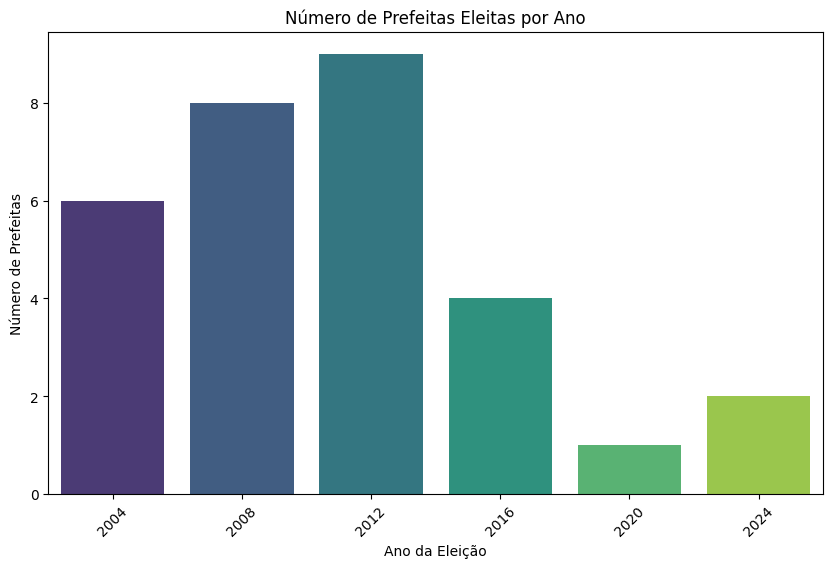

In [197]:
# Contando o número de prefeitas eleitas por ano
prefeitas_por_ano = prefeitas['ANO_ELEICAO'].value_counts().sort_index()

# Criando o gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x=prefeitas_por_ano.index, y=prefeitas_por_ano.values, palette='viridis')
plt.title('Número de Prefeitas Eleitas por Ano')
plt.xlabel('Ano da Eleição')
plt.ylabel('Número de Prefeitas')
plt.xticks(rotation=45)
plt.show()